In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from kuramoto.experiments import evaluate_metric_scores, aggregate_scores, list_metrics
from kuramoto.analysis import get_R, get_R_link
from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)

from kuramoto.plotting import (
    plot_abc_spread_boxplot_h,
    plot_topk_abc_boxplots_h,
    abc_rank_correlation_matrix,
    plot_abc_rank_correlation_heatmap,
    plot_rt_traces_per_case,
    plot_abc_mean_heatmap,
    plot_lesion_r_avg_ranked_overlay,
    color_for_metric,
)

from kuramoto.config import (
    get_components_bottleneck,
    get_groupids_bottleneck,
    get_components_unstructured,
    get_groupids_unstructured,
)

from kuramoto.network import (plot_cortical_graph, create_cortical_graph)
# -----------------------------------------------------------------------------
# Global notebook knobs
# -----------------------------------------------------------------------------

grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

# Ensemble size per case
N_SEEDS = 5
N_SEEDS_SA1A = 20  # larger ensemble for seed-variance study
BASE_SEED = 42

# Lesion study hyperparameters
n_random_repeats = 10
lesion_fracs = np.arange(0, 0.3, 0.02)
lesion_strength = 1.0

# Integrated Gradients quadrature steps
N_IG_STEPS = 10

# Quick mode (set True to iterate faster)
QUICK_MODE = False
if QUICK_MODE:
    N_SEEDS = 1
    N_SEEDS_SA1A = 5
    lesion_fracs = np.arange(0, 0.3, 0.05)
    n_random_repeats = 3
    N_IG_STEPS = 10

### 0) Example networks

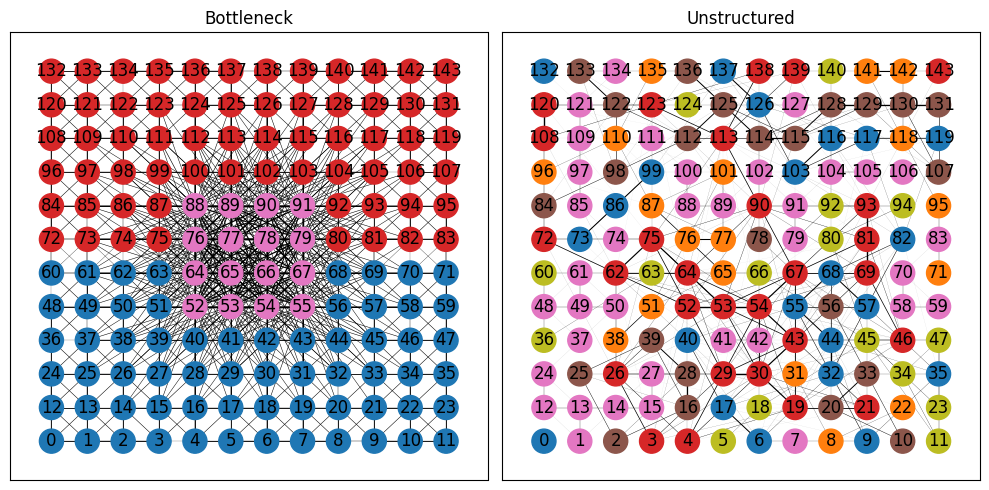

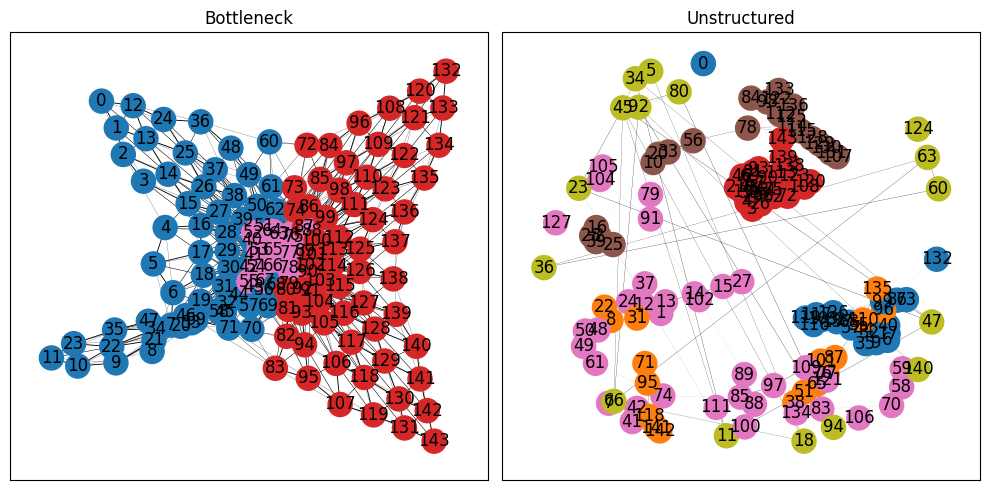

In [2]:
# Bottleneck case
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        components=get_components_bottleneck(seed=42),
        group_ids=get_groupids_bottleneck(grid_shape),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_bottleneck = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_bottleneck = create_cortical_graph(sim_bottleneck)

# Unstructured case
N_GROUPS = 6
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(mode="full", 
                    components=get_components_unstructured(n_groups=N_GROUPS, seed=42, k_factor=1.0), 
                    group_ids=get_groupids_unstructured(grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(42)),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_unstructured = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_unstructured = create_cortical_graph(sim_unstructured)

# Show graph structure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="grid", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="grid", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="spring", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="spring", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

In [3]:
def run_analysis_panel(
    results,
    agg,
    base_Rt,
    case_names,
    labels,
    lesion_fracs,
    seeds,
    metrics,
    n_seeds,
    suptitles=None,
    abc_corr_agg=None,
    abc_corr_case_names=None,
    plot_metrics=None,
    top_k=5,
    panel_prefix="",
):
    """
    Generic panel runner for visualizations given data/analysis inputs.

    Parameters:
        results: Dict of results per case and seed.
        agg: Aggregated metrics/results per case.
        base_Rt: Dict of R(t) per case and seed.
        case_names: Iterable of case/condition keys.
        labels: Dict of display labels per case.
        lesion_fracs: Fractional lesion curve data as required by plotter.
        seeds: Seeds used for runs.
        metrics: List of metrics to show.
        n_seeds: Number of seeds for statistics.
        abc_corr_agg: Agg data for rank-correlation (can be None to skip).
        abc_corr_case_names: Case names for the correlation computation (None to skip).
        plot_metrics: If provided, overlay lesion curves for these metrics.
        top_k: Integer, number of metrics for Top-K boxplots.
        panel_prefix: Optional custom panel identifier for titles (e.g. 'SA1c')
    """
    # Set up default suptitles/titles for each plot at the top of the function
    default_suptitles = [
        f"{panel_prefix}: R(t) Lesion Study (first seed)",
        f"{panel_prefix}: mean ABC",
        f"{panel_prefix}: Top-{top_k} metrics (boxplot, {n_seeds} seeds)",
        f"{panel_prefix}: Rank-correlation of ABC vectors across tested conditions",
        f"{panel_prefix}: Overlay of lesion curves by metric (per condition)",
    ]

    # 1) R(t) sanity traces
    rt_by_case = {c: base_Rt[c][seeds[0]] for c in case_names}
    fig, axs = plot_rt_traces_per_case(
        rt_by_case,
        dt,
        labels,
        suptitle=(
            suptitles[0]
            if suptitles is not None and len(suptitles) > 0
            else default_suptitles[0]
        ),
    )
    plt.show()

    # 2) ABC heatmap: metrics × case
    fig, ax = plot_abc_mean_heatmap(
        agg,
        case_names,
        metrics,
        labels,
        title=(
            suptitles[1]
            if suptitles is not None and len(suptitles) > 1
            else default_suptitles[1]
        ),
    )
    plt.show()

    # 3) Top-K metrics per case
    fig, axs_flat = plot_topk_abc_boxplots_h(
        results,
        agg,
        seeds,
        case_names,
        metrics,
        labels,
        top_k=top_k,
        suptitle=(
            suptitles[2]
            if suptitles is not None and len(suptitles) > 2
            else default_suptitles[2]
        ),
    )
    plt.show()

    # 4) Spearman rank-correlation heatmap (if abc_corr_agg provided)
    # Note: The original code used sa1b_agg and sa1b_case_names. This may be different for other sets!
    if abc_corr_agg is not None and abc_corr_case_names is not None:
        corr = abc_rank_correlation_matrix(abc_corr_agg, abc_corr_case_names)
        fig, ax = plot_abc_rank_correlation_heatmap(
            corr,
            case_names,
            labels,
            title=(
                suptitles[3]
                if suptitles is not None and len(suptitles) > 3
                else default_suptitles[3]
            ),
        )
        plt.show()

    # 5) Lesion curves for selected metrics
    if plot_metrics is not None:
        use_metrics = [m for m in plot_metrics if m in metrics]
    else:
        # Provide a default set
        use_metrics = [m for m in ["betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a"] if m in metrics]

    fig, axs = plot_lesion_r_avg_ranked_overlay(
        lesion_fracs,
        case_names,
        labels,
        agg,
        use_metrics,
        suptitle=(
            suptitles[4]
            if suptitles is not None and len(suptitles) > 4
            else default_suptitles[4]
        ),
    )
    plt.show()

### 1a) Seed variance
Quantify how much ABC scores fluctuate from random initialization alone (single IC configuration, many seeds). This determines the ensemble size needed for downstream analyses.

In [5]:
sa1a_seeds = [BASE_SEED + i for i in range(N_SEEDS_SA1A)]

sa1a_results: dict[int, dict] = {}

for seed in sa1a_seeds:
    print(f"SA1a seed={seed}")
    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            mode="spatial",
            components=get_components_bottleneck(),
            group_ids=get_groupids_bottleneck(grid_shape),
        ),
        initial_theta=InitThetaConfig(mode="uniform"),
        initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
        seed=seed,
    )
    sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

    sa1a_results[seed] = evaluate_metric_scores(
        sim, T_END, dt, np.random.default_rng(seed),
        n_random_repeats=n_random_repeats,
        lesion_fracs=lesion_fracs,
        lesion_strength=lesion_strength,
        n_ig_steps=N_IG_STEPS,
        verbose=False,
        base_seed=seed,
    )

print(f"\nDone – {len(sa1a_results)} seeds collected.")

SA1a seed=42
SA1a seed=43
SA1a seed=44
SA1a seed=45
SA1a seed=46
SA1a seed=47
SA1a seed=48
SA1a seed=49
SA1a seed=50
SA1a seed=51
SA1a seed=52
SA1a seed=53
SA1a seed=54
SA1a seed=55
SA1a seed=56
SA1a seed=57
SA1a seed=58
SA1a seed=59
SA1a seed=60
SA1a seed=61

Done – 20 seeds collected.


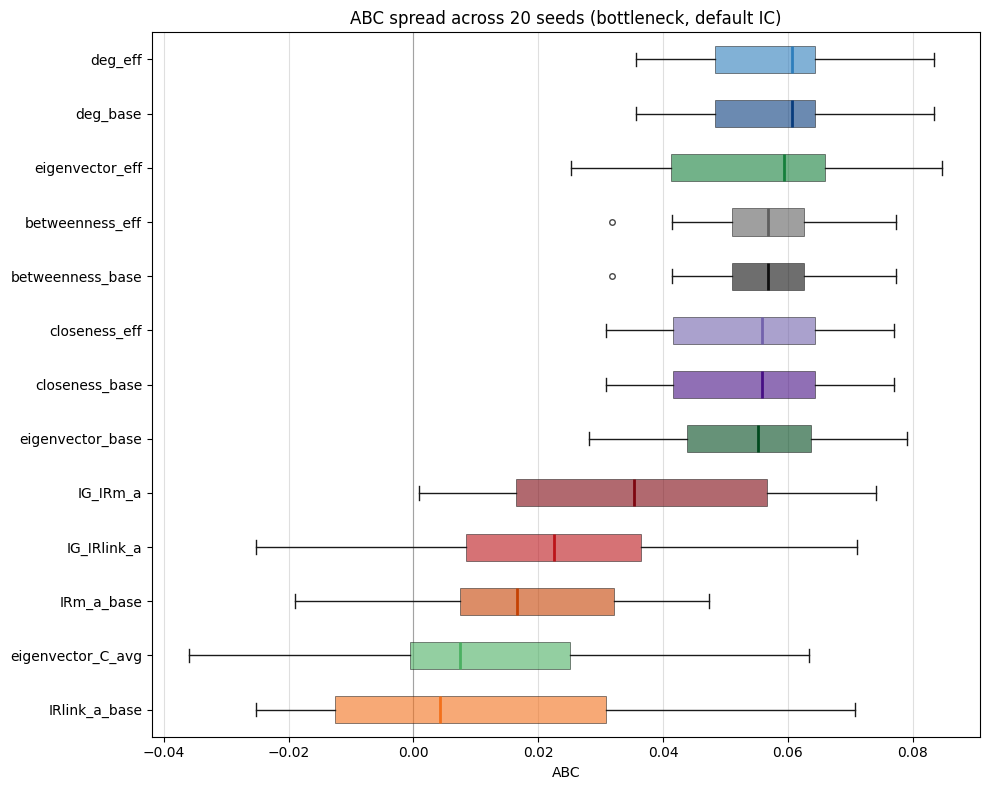

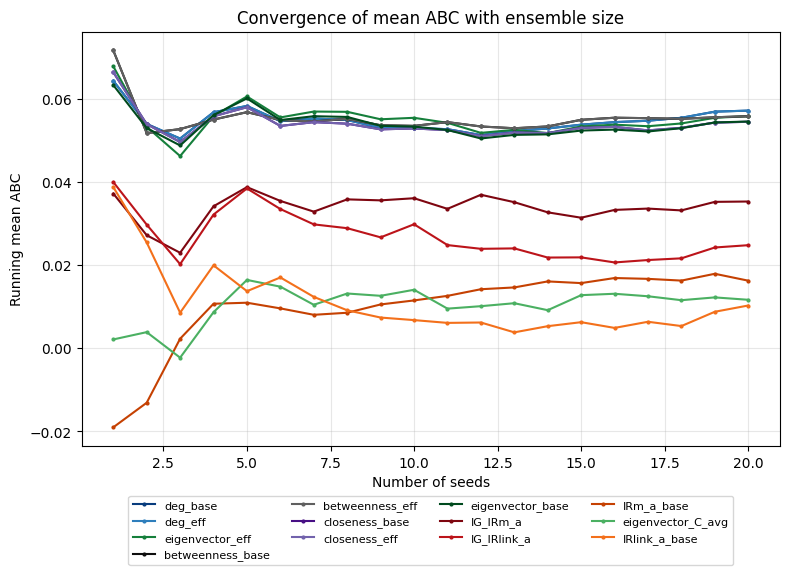

In [6]:
metrics_sa1a = sorted(sa1a_results[sa1a_seeds[0]].keys())
abc_by_metric = {m: [sa1a_results[s][m]["ABC"] for s in sa1a_seeds] for m in metrics_sa1a}

# ── 1) ABC box plot across seeds ──────────────────────────────────────────────
fig, ax = plot_abc_spread_boxplot_h(
    abc_by_metric,
    title=f"ABC spread across {N_SEEDS_SA1A} seeds (bottleneck, default IC)",
    patch_alpha=0.6,
)
plt.show()

# ── 2) Convergence of running mean ABC for top-K metrics ─────────────────────
TOP_K_CONV = len(metrics_sa1a)
top_metrics = sorted(metrics_sa1a, key=lambda m: np.median(abc_by_metric[m]), reverse=True)[:TOP_K_CONV]

fig, ax = plt.subplots(figsize=(8, 6))
for m in top_metrics:
    vals = np.array(abc_by_metric[m])
    running_mean = np.cumsum(vals) / np.arange(1, len(vals) + 1)
    ax.plot(np.arange(1, len(vals) + 1), running_mean, label=m, marker=".", ms=4, color = color_for_metric(m))

ax.set_xlabel("Number of seeds")
ax.set_ylabel("Running mean ABC")
ax.set_title("Convergence of mean ABC with ensemble size")
ax.legend(fontsize=8, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.3))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1b) Theta sensitivity
Fix omega distribution (normal, sigma=0.3) and vary the spread of the initial phase distribution theta_0. Uses a normal distribution with increasing sigma.

In [7]:
sa1b_theta_gammas = [0.5, 1.0, 2.0, 4.0]
seeds = [BASE_SEED + i for i in range(N_SEEDS)]

FIXED_OMEGA_SIGMA = 0.3

sa1b_results: dict[str, dict[int, dict]] = {}
sa1b_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa1b_labels: dict[str, str] = {}

for theta_gamma in sa1b_theta_gammas:
    case_key = f"theta_gamma={theta_gamma}"
    sa1b_labels[case_key] = f"θγ={theta_gamma}"
    sa1b_results[case_key] = {}
    sa1b_base_Rt[case_key] = {}

    theta_cfg = InitThetaConfig(mode="vonmises", mu=0.0, gamma=theta_gamma)
    omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=FIXED_OMEGA_SIGMA)

    for seed in seeds:
        print(f"SA1b  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=get_components_bottleneck(),
                group_ids=get_groupids_bottleneck(grid_shape),
            ),
            initial_theta=theta_cfg,
            initial_omega=omega_cfg,
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = get_R(res["theta"])
        sa1b_base_Rt[case_key][seed] = np.asarray(Rt)

        sa1b_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
            base_seed=seed,
        )

sa1b_agg = aggregate_scores(sa1b_results)
sa1b_case_names = list(sa1b_results.keys())
print(f"\nDone – {len(sa1b_case_names)} θ-sigma values × {N_SEEDS} seeds.")

SA1b  theta_gamma=0.5  seed=42
SA1b  theta_gamma=0.5  seed=43
SA1b  theta_gamma=0.5  seed=44
SA1b  theta_gamma=0.5  seed=45
SA1b  theta_gamma=0.5  seed=46
SA1b  theta_gamma=1.0  seed=42
SA1b  theta_gamma=1.0  seed=43
SA1b  theta_gamma=1.0  seed=44
SA1b  theta_gamma=1.0  seed=45
SA1b  theta_gamma=1.0  seed=46
SA1b  theta_gamma=2.0  seed=42
SA1b  theta_gamma=2.0  seed=43
SA1b  theta_gamma=2.0  seed=44
SA1b  theta_gamma=2.0  seed=45
SA1b  theta_gamma=2.0  seed=46
SA1b  theta_gamma=4.0  seed=42
SA1b  theta_gamma=4.0  seed=43
SA1b  theta_gamma=4.0  seed=44
SA1b  theta_gamma=4.0  seed=45
SA1b  theta_gamma=4.0  seed=46

Done – 4 θ-sigma values × 5 seeds.


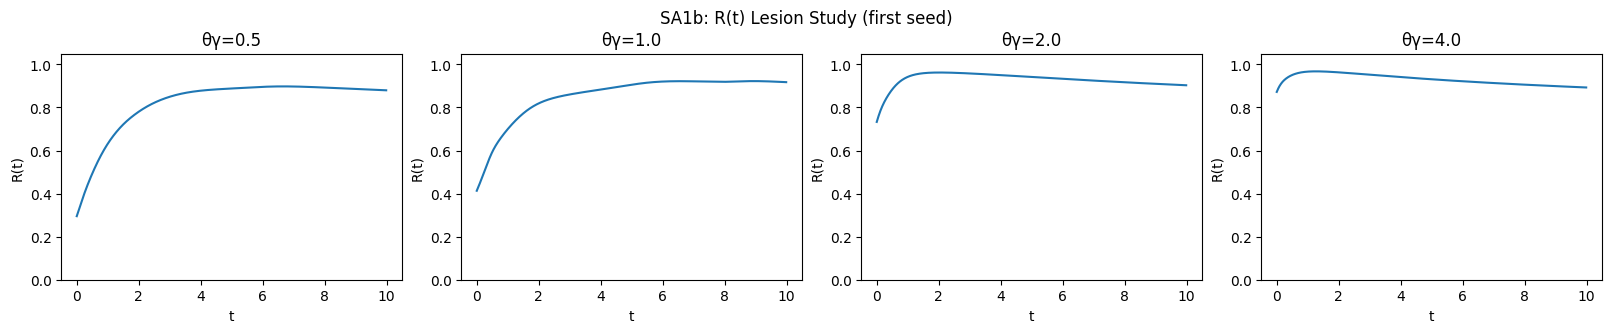

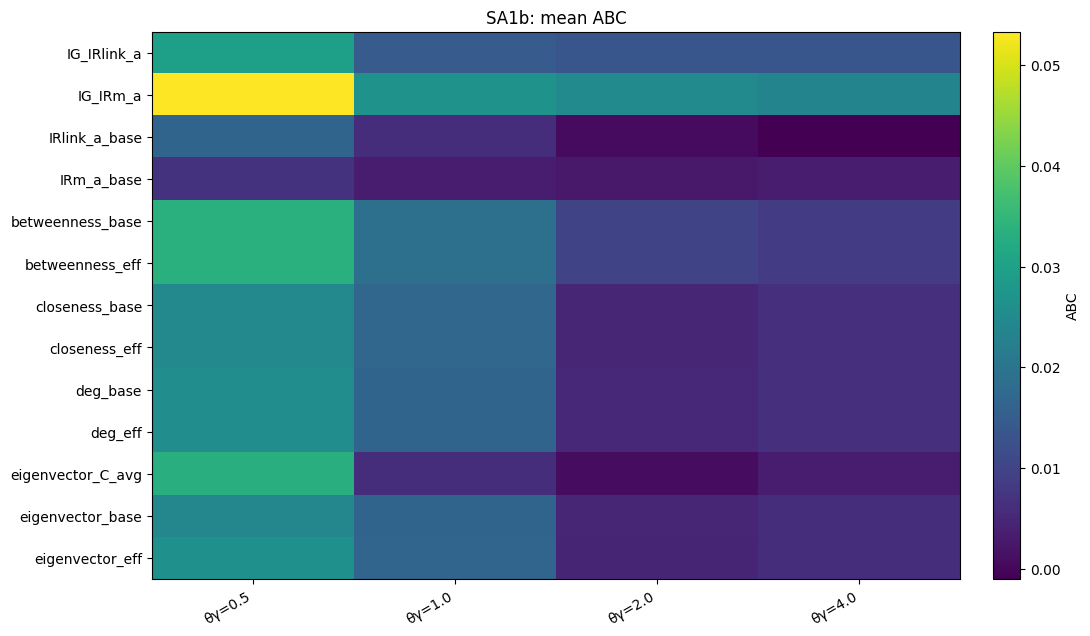

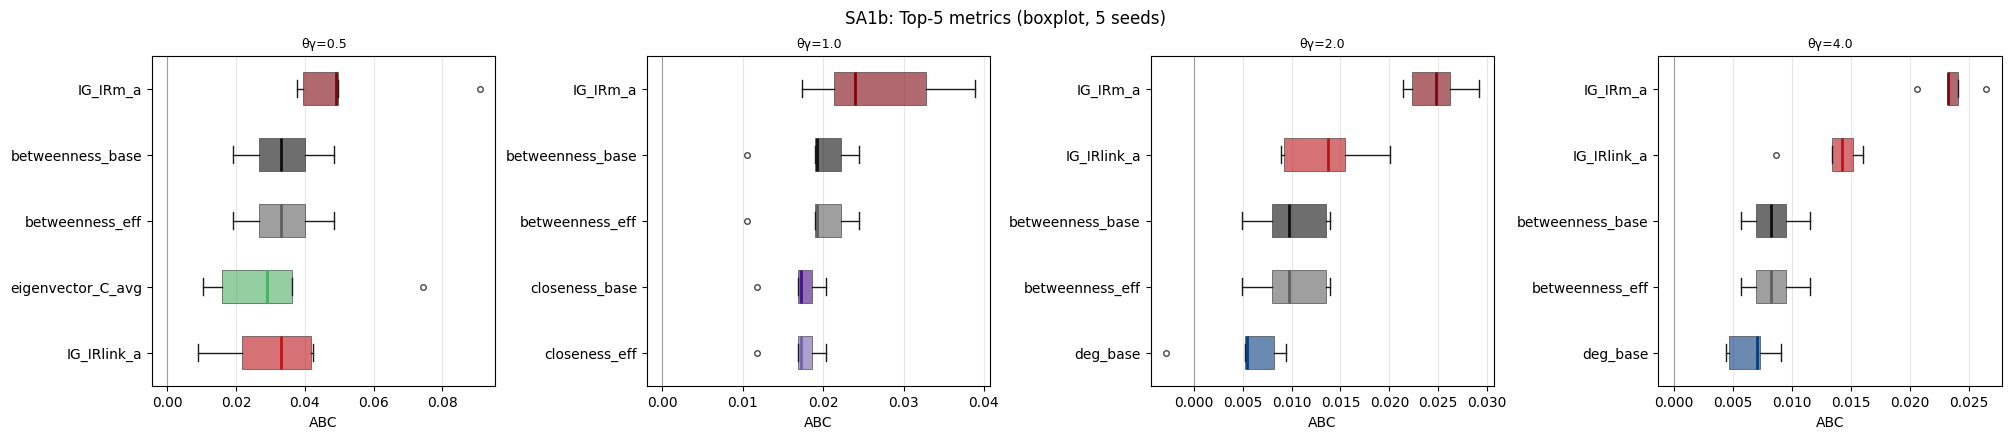

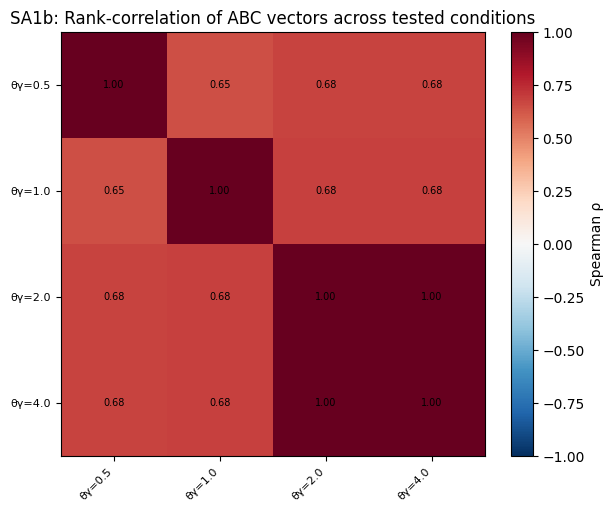

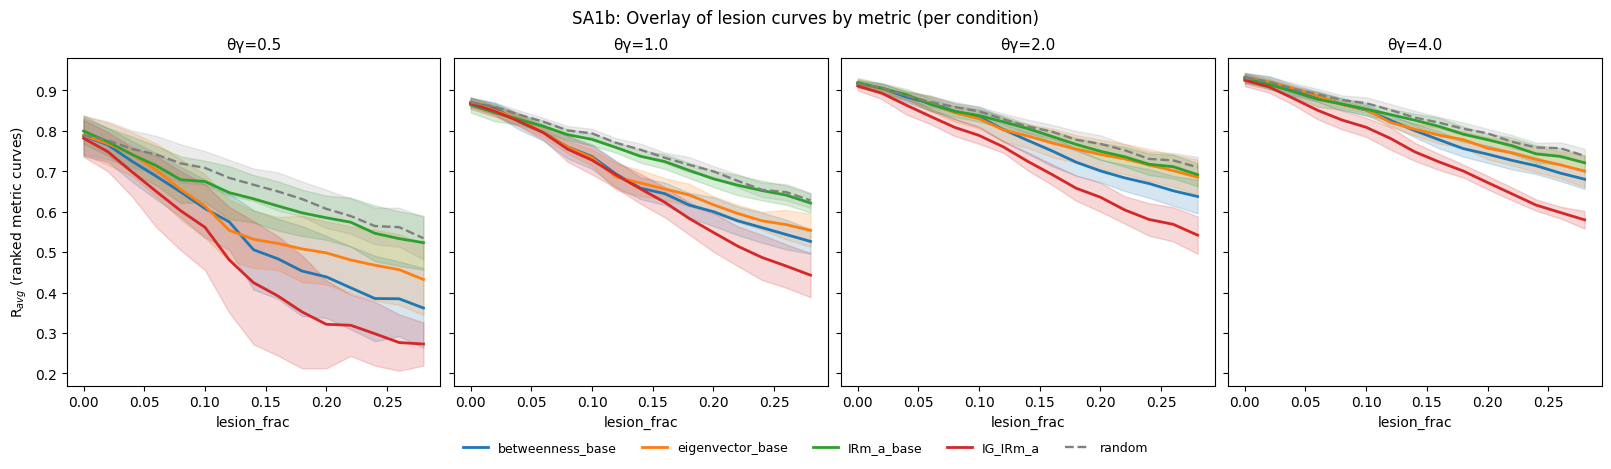

In [8]:
metrics_sa1b = sa1b_agg[sa1b_case_names[0]]["metrics"]
run_analysis_panel(
    results=sa1b_results,
    agg=sa1b_agg,
    base_Rt=sa1b_base_Rt,
    case_names=sa1b_case_names,
    labels=sa1b_labels,
    lesion_fracs=lesion_fracs,
    seeds=seeds,
    metrics=metrics_sa1b,
    n_seeds=N_SEEDS,
    abc_corr_agg=sa1b_agg,
    abc_corr_case_names=sa1b_case_names,
    plot_metrics=["betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a"],
    top_k=5,
    panel_prefix="SA1b",
)

Findings:
Gradient metrics outperform network metrics close to synchronization which makes sense as the gradients are less noisy. Interestingly as initial desynchronization linearized gradients (not integrated) become ineffective, but the integrated R gradient stays in top 3. This also follows expectations and shows the integrated gradients improve robustness.

### 1c) Omega sensitivity
Fix theta distribution (uniform) and vary the spread of the natural frequency distribution omega_0. Uses a normal distribution with increasing sigma.

In [9]:
sa1c_omega_sigmas = [0.1, 0.3, 0.5, 1.0]

FIXED_THETA_MODE = "vonmises"
FIXED_THETA_GAMMA = 0.5

sa1c_results: dict[str, dict[int, dict]] = {}
sa1c_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa1c_labels: dict[str, str] = {}

for omega_sig in sa1c_omega_sigmas:
    case_key = f"omega_sig={omega_sig}"
    sa1c_labels[case_key] = f"ωσ={omega_sig}"
    sa1c_results[case_key] = {}
    sa1c_base_Rt[case_key] = {}

    theta_cfg = InitThetaConfig(mode=FIXED_THETA_MODE, gamma=FIXED_THETA_GAMMA)
    omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=omega_sig)

    for seed in seeds:
        print(f"SA1c  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=get_components_bottleneck(),
                group_ids=get_groupids_bottleneck(grid_shape),
            ),
            initial_theta=theta_cfg,
            initial_omega=omega_cfg,
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = get_R(res["theta"])
        sa1c_base_Rt[case_key][seed] = np.asarray(Rt)

        sa1c_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
            base_seed=seed,
        )

sa1c_agg = aggregate_scores(sa1c_results)
sa1c_case_names = list(sa1c_results.keys())
print(f"\nDone – {len(sa1c_case_names)} ω-sigma values × {N_SEEDS} seeds.")

SA1c  omega_sig=0.1  seed=42
SA1c  omega_sig=0.1  seed=43
SA1c  omega_sig=0.1  seed=44
SA1c  omega_sig=0.1  seed=45
SA1c  omega_sig=0.1  seed=46
SA1c  omega_sig=0.3  seed=42
SA1c  omega_sig=0.3  seed=43
SA1c  omega_sig=0.3  seed=44
SA1c  omega_sig=0.3  seed=45
SA1c  omega_sig=0.3  seed=46
SA1c  omega_sig=0.5  seed=42
SA1c  omega_sig=0.5  seed=43
SA1c  omega_sig=0.5  seed=44
SA1c  omega_sig=0.5  seed=45
SA1c  omega_sig=0.5  seed=46
SA1c  omega_sig=1.0  seed=42
SA1c  omega_sig=1.0  seed=43
SA1c  omega_sig=1.0  seed=44
SA1c  omega_sig=1.0  seed=45
SA1c  omega_sig=1.0  seed=46

Done – 4 ω-sigma values × 5 seeds.


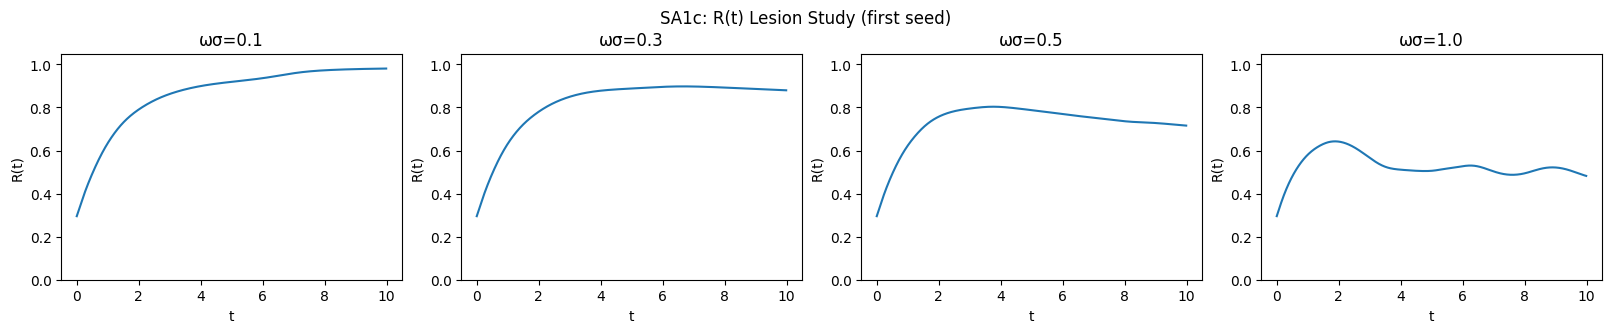

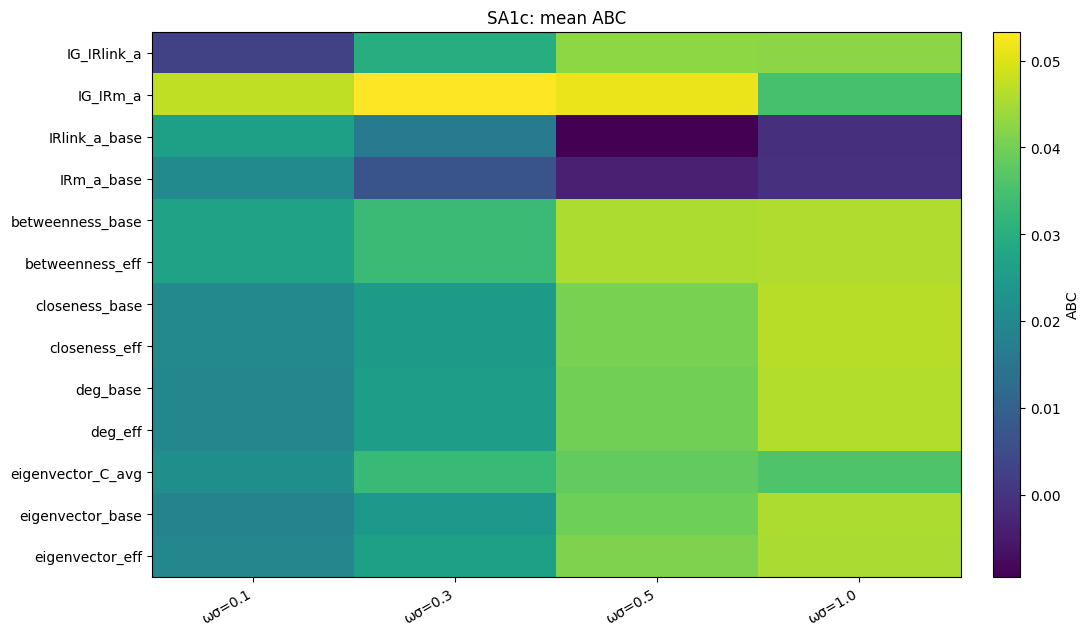

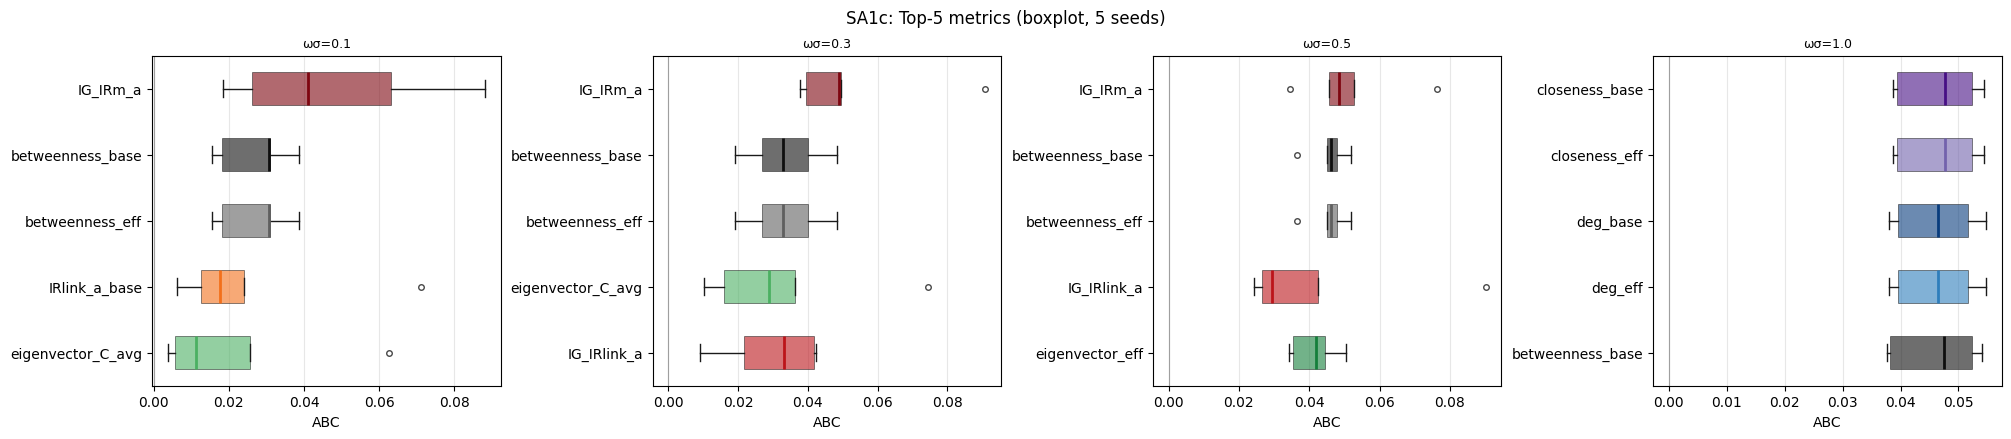

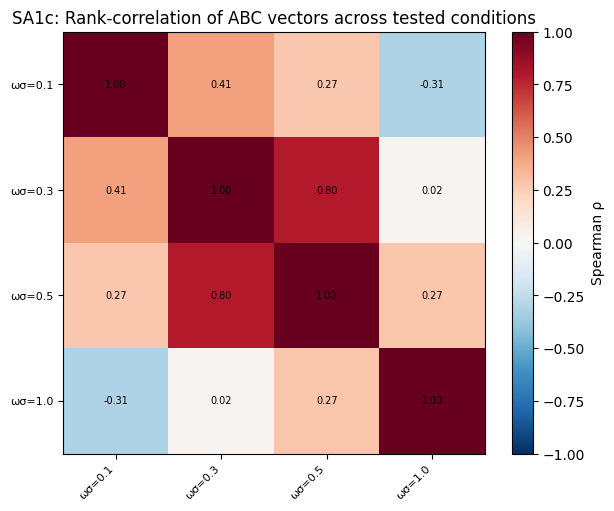

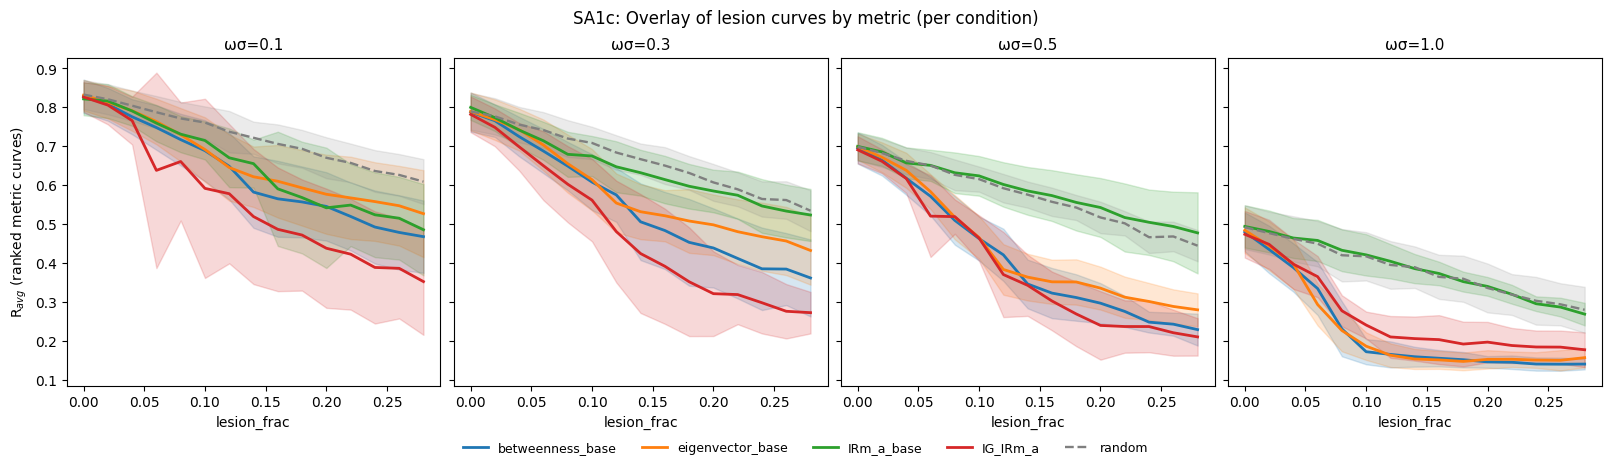

In [10]:
metrics_sa1c = sa1c_agg[sa1c_case_names[0]]["metrics"]
run_analysis_panel(
    results=sa1c_results,
    agg=sa1c_agg,
    base_Rt=sa1c_base_Rt,
    case_names=sa1c_case_names,
    labels=sa1c_labels,
    lesion_fracs=lesion_fracs,
    seeds=seeds,
    metrics=metrics_sa1c,
    n_seeds=N_SEEDS,
    abc_corr_agg=sa1c_agg,
    abc_corr_case_names=sa1c_case_names,
    plot_metrics=["betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a"],
    top_k=5,
    panel_prefix="SA1c",
)

Findings:
gradient based methods are again most effective with narrow omega0 distributions, but lose effectiveness with bigger gaps. IGRm_a is more robust to this initialization and has highest score until omega = 0.5, but at the widest distribution it isnt even in top 8. The graients are likely too disordered when the oscillator frequencies are too dispersed. The ABCs are particularly large at this wide distribution - the possibility that the progressive lesioning and ABC score are biased also cannot be discarded.

### 2) Coupling strength sensitivity
Run lesion studies on bottleneck case with varying coupling strength. Compare metric scores across cases.

In [11]:
sa2_k_factors = [0.25, 0.5, 1.0, 2.0, 4.0]

sa2_results: dict[str, dict[int, dict]] = {}
sa2_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa2_labels: dict[str, str] = {}

for kf in sa2_k_factors:
    case_key = f"k={kf}"
    sa2_labels[case_key] = f"K×{kf}"
    sa2_results[case_key] = {}
    sa2_base_Rt[case_key] = {}

    for seed in seeds:
        print(f"SA2  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=get_components_bottleneck(k_factor=kf),
                group_ids=get_groupids_bottleneck(grid_shape),
            ),
            initial_theta=InitThetaConfig(mode="vonmises"),
            initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = get_R(res["theta"])
        sa2_base_Rt[case_key][seed] = np.asarray(Rt)

        sa2_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
            base_seed=seed,
        )

sa2_agg = aggregate_scores(sa2_results)
sa2_case_names = list(sa2_results.keys())
print(f"\nDone – {len(sa2_case_names)} k_factors × {N_SEEDS} seeds.")

SA2  k=0.25  seed=42
SA2  k=0.25  seed=43
SA2  k=0.25  seed=44
SA2  k=0.25  seed=45
SA2  k=0.25  seed=46
SA2  k=0.5  seed=42
SA2  k=0.5  seed=43
SA2  k=0.5  seed=44
SA2  k=0.5  seed=45
SA2  k=0.5  seed=46
SA2  k=1.0  seed=42
SA2  k=1.0  seed=43
SA2  k=1.0  seed=44
SA2  k=1.0  seed=45
SA2  k=1.0  seed=46
SA2  k=2.0  seed=42
SA2  k=2.0  seed=43
SA2  k=2.0  seed=44
SA2  k=2.0  seed=45
SA2  k=2.0  seed=46
SA2  k=4.0  seed=42
SA2  k=4.0  seed=43
SA2  k=4.0  seed=44
SA2  k=4.0  seed=45
SA2  k=4.0  seed=46

Done – 5 k_factors × 5 seeds.


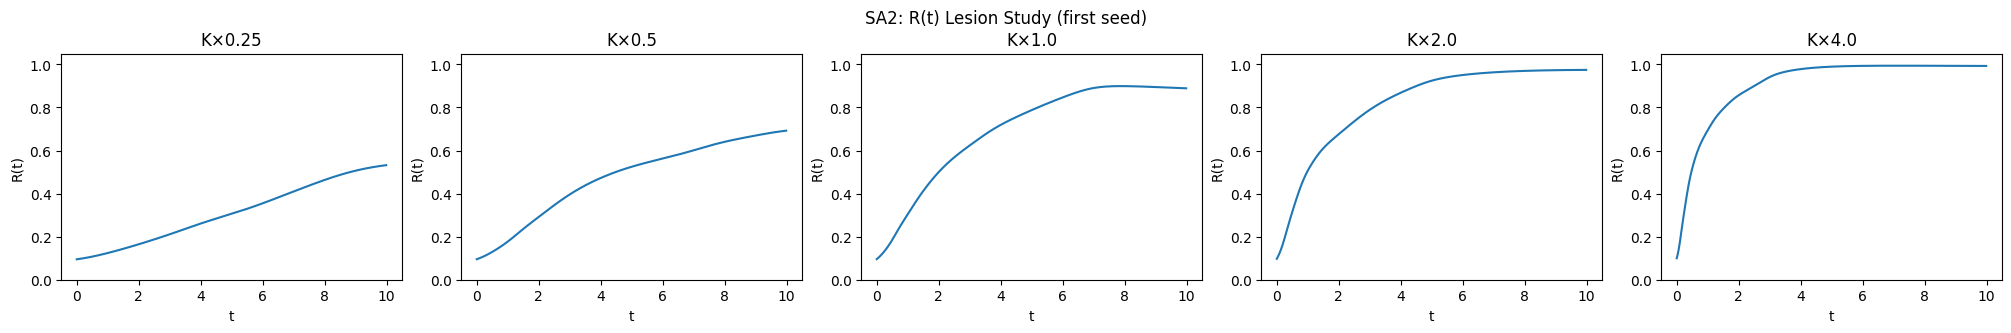

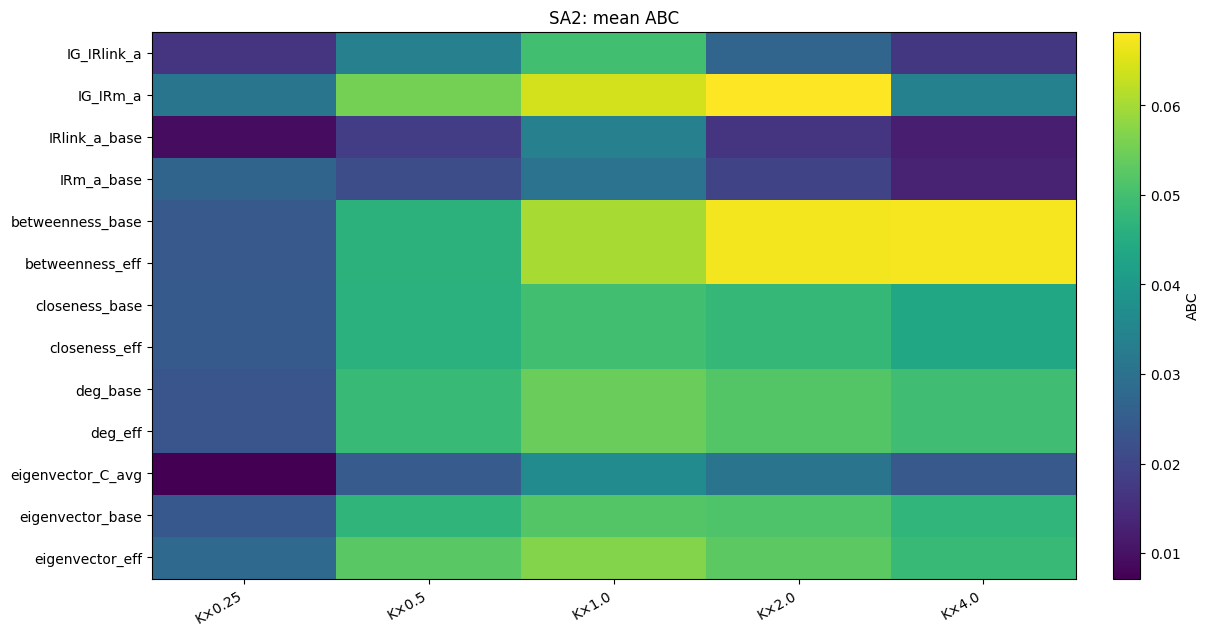

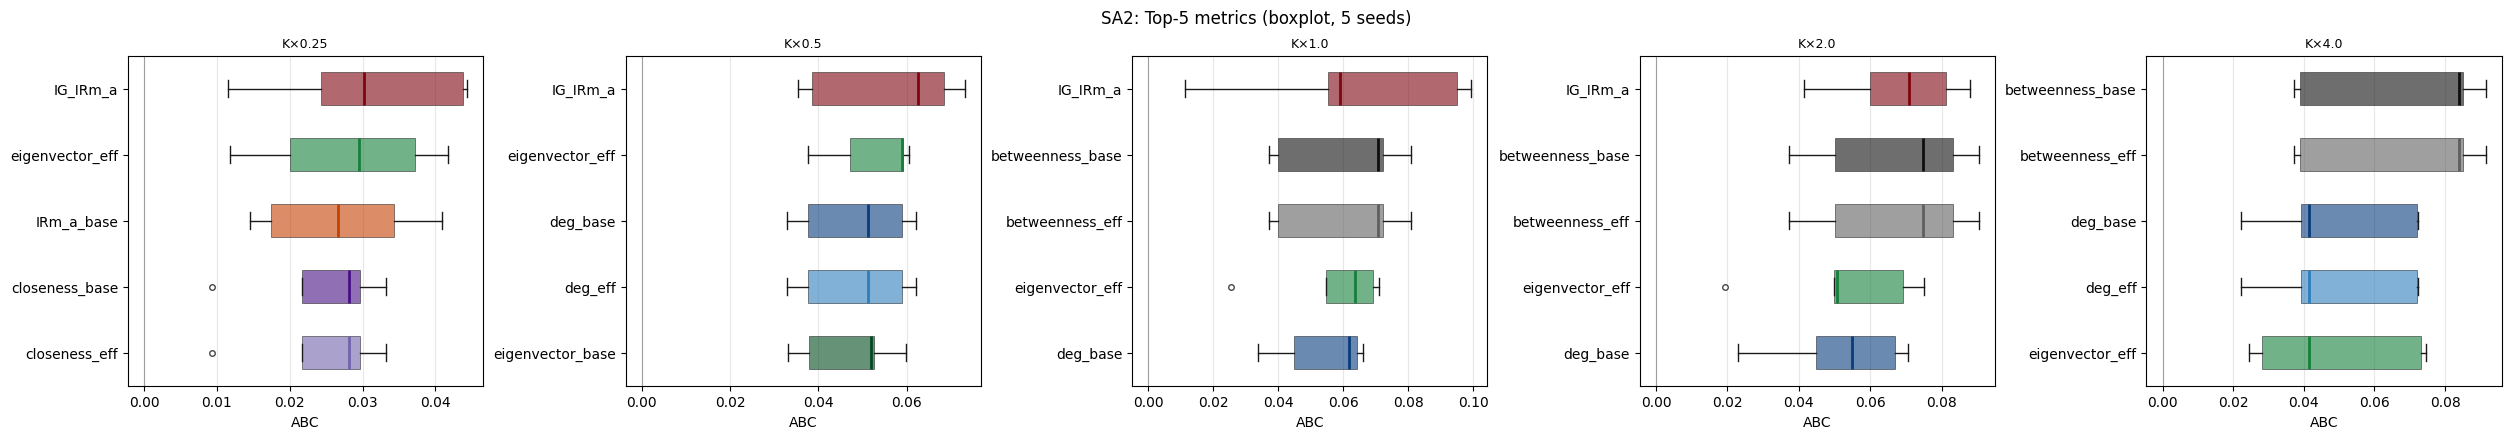

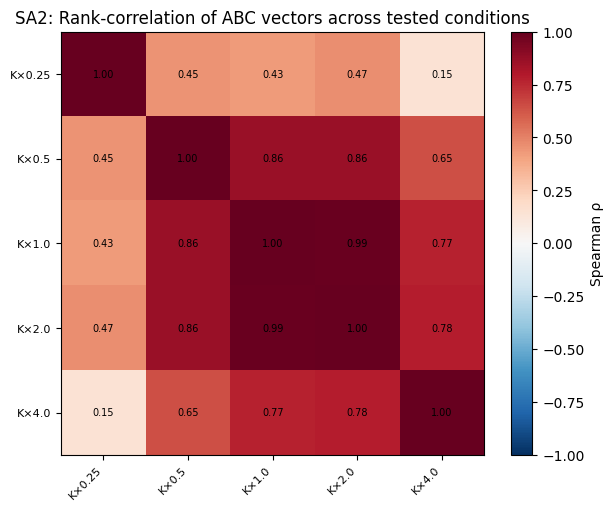

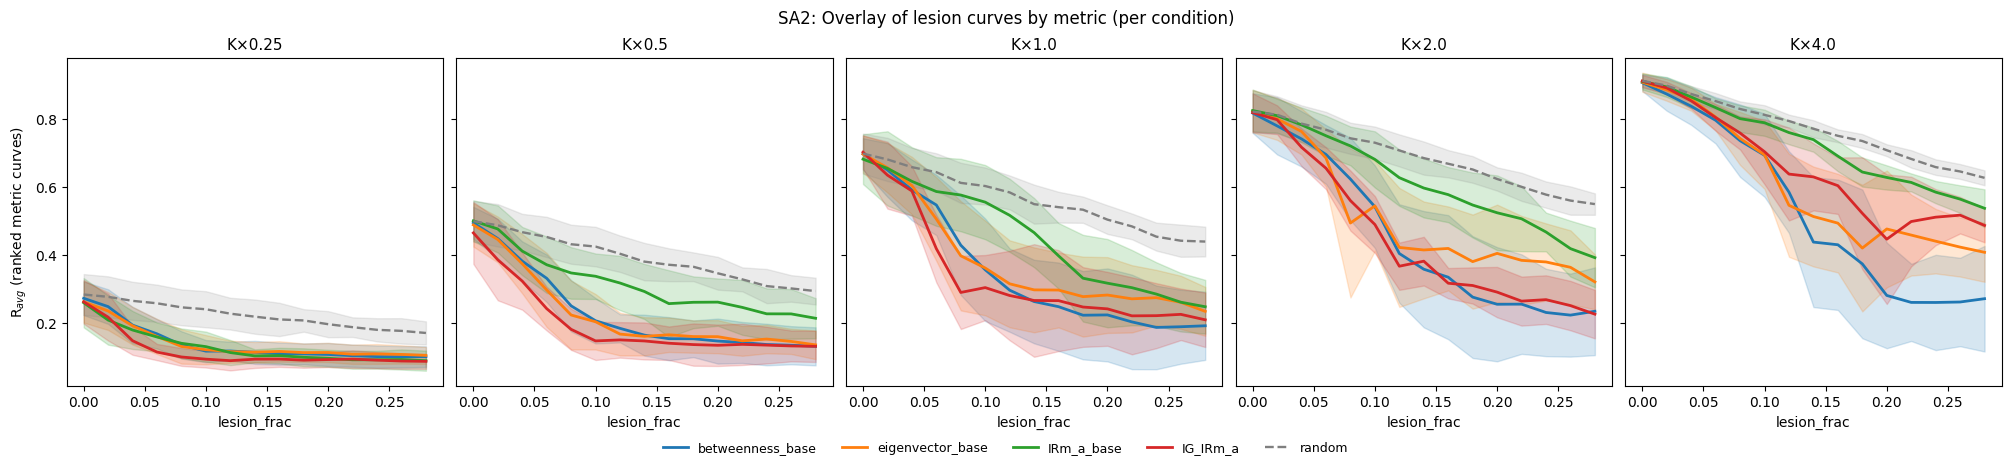

In [12]:
metrics_sa2 = sa2_agg[sa2_case_names[0]]["metrics"]
run_analysis_panel(
    results=sa2_results,
    agg=sa2_agg,
    base_Rt=sa2_base_Rt,
    case_names=sa2_case_names,
    labels=sa2_labels,
    lesion_fracs=lesion_fracs,
    seeds=seeds,
    metrics=metrics_sa2,
    n_seeds=N_SEEDS,
    abc_corr_agg=sa2_agg,
    abc_corr_case_names=sa2_case_names,
    plot_metrics=["betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a"],
    top_k=5,
    panel_prefix="SA2",
)

### 3) Structural sensitivity
Compare bottleneck and unstructured network.

In [ ]:
seeds = [BASE_SEED + i for i in range(N_SEEDS)]

theta_cfg = InitThetaConfig(mode="vonmises", gamma=0.5)
omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=0.5)

struct3_results: dict[str, dict[int, dict]] = {}
struct3_base_Rt: dict[str, dict[int, np.ndarray]] = {}
struct3_labels = {
    "bottleneck": "Bottleneck",
    "unstructured": "Unstructured",
}

for case_key in ("bottleneck", "unstructured"):
    struct3_results[case_key] = {}
    struct3_base_Rt[case_key] = {}

    for seed in seeds:
        print(f"{struct3_labels[case_key]:<14}  seed={seed}")

        if case_key == "bottleneck":
            cfg = SimulationConfig(
                grid=GridConfig(shape=grid_shape, periodic=False),
                coupling=CouplingConfig(
                    mode="spatial",
                    components=get_components_bottleneck(seed=BASE_SEED),
                    group_ids=get_groupids_bottleneck(grid_shape),
                ),
                initial_theta=theta_cfg,
                initial_omega=omega_cfg,
                seed=seed,
            )
        else:
            cfg = SimulationConfig(
                grid=GridConfig(shape=grid_shape, periodic=False),
                coupling=CouplingConfig(
                    mode="spatial",
                    components=get_components_unstructured(
                        n_groups=N_GROUPS, seed=BASE_SEED, k_factor=1.0
                    ),
                    group_ids=get_groupids_unstructured(
                        grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(BASE_SEED)
                    ),
                ),
                initial_theta=theta_cfg,
                initial_omega=omega_cfg,
                seed=seed,
            )

        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))
        res = sim.run((0, T_END), dt)
        Rt, _ = get_R(res["theta"])
        struct3_base_Rt[case_key][seed] = np.asarray(Rt)

        struct3_results[case_key][seed] = evaluate_metric_scores(
            sim,
            T_END,
            dt,
            np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            n_ig_steps=N_IG_STEPS,
            verbose=False,
            base_seed=seed,
        )

struct3_agg = aggregate_scores(struct3_results)
struct3_case_names = list(struct3_results.keys())
print(f"\nDone – {len(struct3_case_names)} structures × {N_SEEDS} seeds.")

Bottleneck      seed=42
Bottleneck      seed=43
Bottleneck      seed=44
Bottleneck      seed=45
Bottleneck      seed=46
Unstructured    seed=42
Unstructured    seed=43
Unstructured    seed=44
Unstructured    seed=45
Eigenvector centrality failed to converge, returning NaNs
Eigenvector centrality failed to converge, returning NaNs
Unstructured    seed=46

Done – 2 structures × 5 seeds.


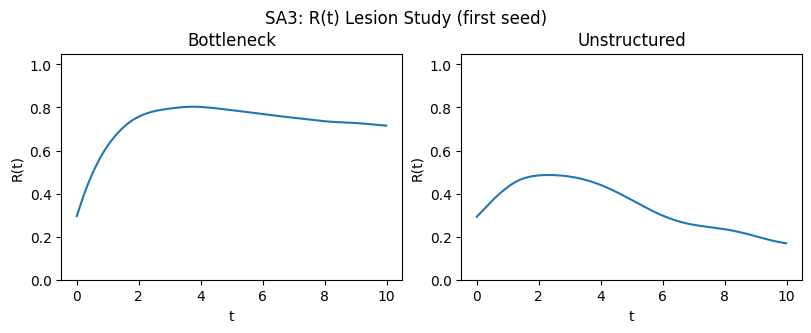

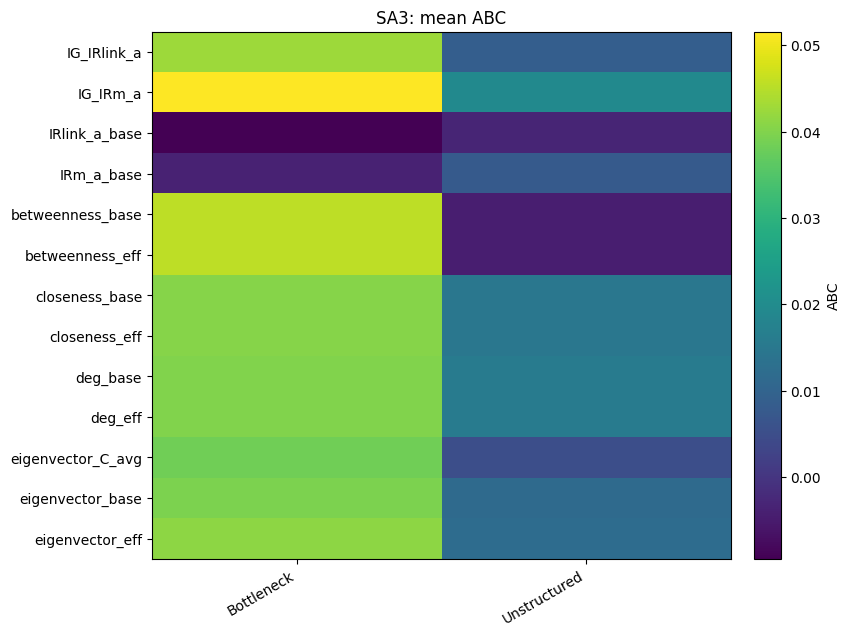

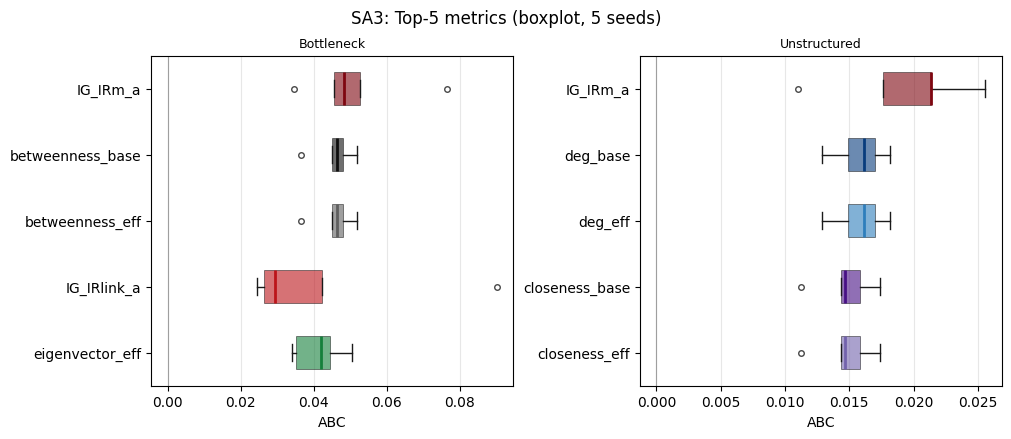

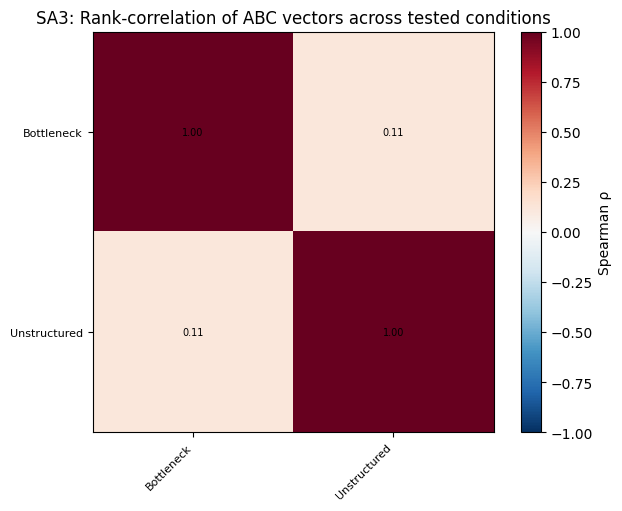

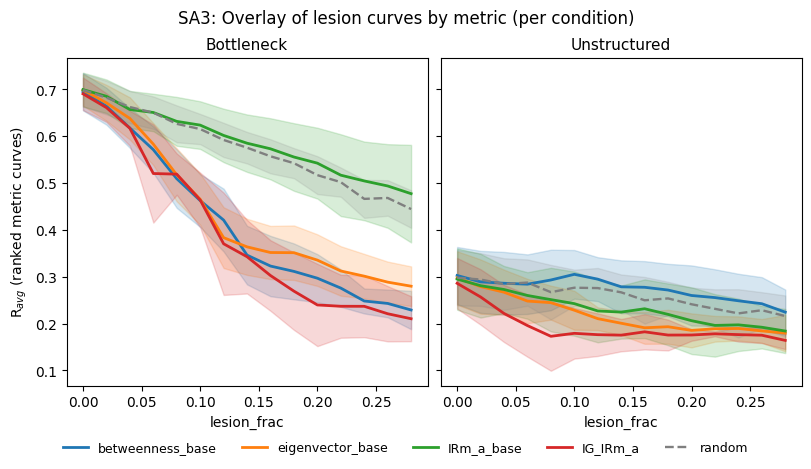

In [ ]:
metrics_sa3 = struct3_agg[struct3_case_names[0]]["metrics"]
run_analysis_panel(
    results=struct3_results,
    agg=struct3_agg,
    base_Rt=struct3_base_Rt,
    case_names=struct3_case_names,
    labels=struct3_labels,
    lesion_fracs=lesion_fracs,
    seeds=seeds,
    metrics=metrics_sa3,
    n_seeds=N_SEEDS,
    abc_corr_agg=struct3_agg,
    abc_corr_case_names=struct3_case_names,
    plot_metrics=["betweenness_base", "eigenvector_base", "IRm_a_base", "IG_IRm_a"],
    top_k=5,
    panel_prefix="SA3",
)